In [63]:
import pickle as pkl
import numpy as np
from matplotlib import pyplot as plt
from glob import glob
import pandas as pd
from scipy import stats
import seaborn as sns
import bambi as bmb
import arviz as az

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [28]:
import statsmodels.formula.api as smf

In [29]:
df_all = pd.read_parquet("../data/generated/engagement_zero_contrast_scaled.pqt")

In [32]:
df_old = pd.read_parquet("../data/generated/engagement_zero_contrast.pqt")

In [33]:
df_all["is_correct"] = (df_all["feedbackType"] == 1).astype(int)
df_old["is_correct"] = (df_old["feedbackType"] == 1).astype(int)

In [43]:
df_all["actual_reward_side"] = np.where(
    df_all["is_correct"] == True, df_all["choice"], -df_all["choice"]
)

In [45]:
df_all["block_side"] = np.where(df_all["probabilityLeft"] == 0.8, 1, -1)

In [49]:
from brainwidemap.bwm_loading import bwm_query, bwm_units, load_trials_and_mask, merge_probes
from one.api import ONE

In [47]:
one = ONE(mode="local")
bwm_df = bwm_query(one)
runonalleids = bwm_df["eid"].unique()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv


In [50]:
trials, mask = load_trials_and_mask(
    one,
    runonalleids[0],
    exclude_nochoice=False,
    exclude_unbiased=True,
)

In [53]:
df_all["is_congruent"] = (df_all["block_side"] == df_all["actual_reward_side"]).astype(int)

In [62]:
# fit : is_correct ~ is_congruent + engagement + (1 | eid)

In [65]:
model = bmb.Model(
    "is_correct ~ is_congruent + engagement + (1 | eid)", data=df_all, family="bernoulli"
)

In [66]:
results = model.fit(draws=2000, tune=1000, chains=4)

Modeling the probability that is_correct==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, is_congruent, engagement, 1|eid_sigma, 1|eid_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 34 seconds.


In [73]:
summary_df = az.summary(results, var_names=["Intercept", "is_congruent", "engagement"])

# Rename columns to be more intuitive for a results table
summary_df = summary_df[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]]

In [74]:
summary_df

,mean,sd,hdi_3%,hdi_97%,r_hat
Intercept,-1.261,0.080,-1.415,-1.111,1.0
is_congruent,1.511,0.041,1.433,1.586,1.0
engagement,0.716,0.102,0.527,0.911,1.0


In [76]:
az.summary(results, var_names=["Intercept", "is_congruent", "engagement"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.261,0.080,-1.415,-1.111,0.001,0.001,12053.0,6137.0,1.0
is_congruent,1.511,0.041,1.433,1.586,0.000,0.001,16380.0,5232.0,1.0
engagement,0.716,0.102,0.527,0.911,0.001,0.001,11924.0,6385.0,1.0


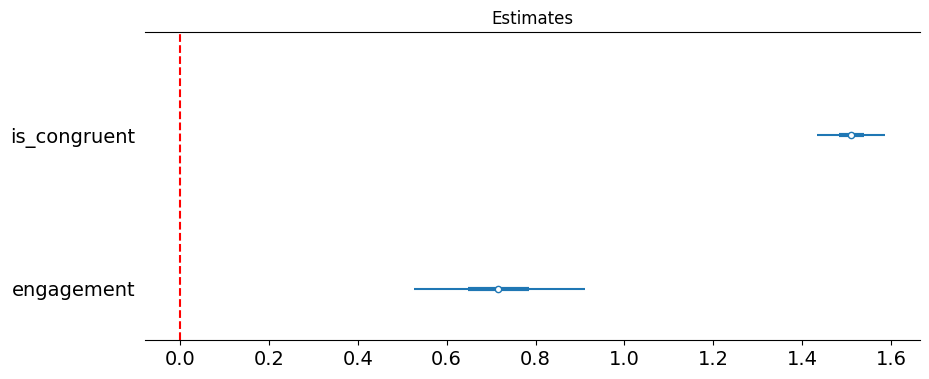

In [88]:
az.plot_forest(results, var_names=["is_congruent", "engagement"], combined=True, figsize=(10, 4))

plt.axvline(0, color="red", linestyle="--")  # Add a reference line at zero
plt.title("Estimates")
plt.show()

array([[<Axes: title={'center': 'is_congruent'}>,
        <Axes: title={'center': 'is_congruent'}>],
       [<Axes: title={'center': 'engagement'}>,
        <Axes: title={'center': 'engagement'}>]], dtype=object)

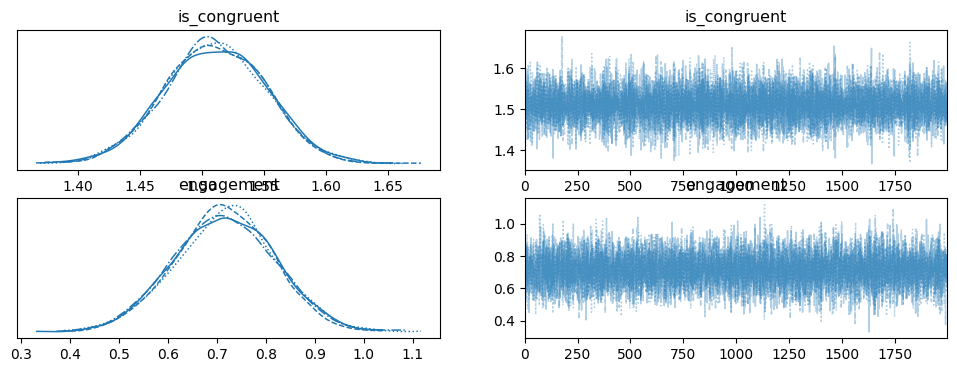

In [83]:
az.plot_trace(results, var_names=["is_congruent", "engagement"])

In [89]:
az.summary(results, var_names=["engagement"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
engagement,0.716,0.102,0.527,0.911,0.001,0.001,11924.0,6385.0,1.0
